In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [50]:
df = pd.read_csv("../data/data_with_risk_classes.csv")  

# If your columns have different names, set them here:
#RISK_SCORE_COL = "Risk_Score"
RISK_CLASS_COL = "Risk_Class"     # 0 = Low, 1 = Medium, 2 = High
TARGET_PREMIUM_COL = "Premium Amount"

In [51]:
inc_p25, inc_p50, inc_p75 = df['Annual Income'].quantile([0.25, 0.5, 0.75])
health_p25, health_p50, health_p75 = df['Health Score'].quantile([0.25, 0.5, 0.75])

print("Income thresholds:", inc_p25, inc_p50, inc_p75)
print("Health thresholds:", health_p25, health_p50, health_p75)

Income thresholds: 8001.0 23911.0 44634.0
Health thresholds: 15.918958725500936 24.57864816412784 34.52720946408295


In [52]:
def compute_rule_based_premium(row, 
                                  inc_p25=inc_p25, inc_p75=inc_p75, 
                                  health_p25=health_p25, health_p75=health_p75):
    """
    Rule-Based Premium Model (Aligned with Enhanced Manual Risk Index v2).
    Follows the same risk philosophy:
    - Adaptive percentile thresholds for income and health
    - Strong penalties for smoking + high claims
    - Mild penalties for age, credit, vehicle age, exercise, dependents
    
    The goal is to preserve interpretability + consistency.
    """
    
    base = 500
    
    # ----------------------------------------
    # AGE FACTOR
    # ----------------------------------------
    age = row["Age"]
    if age < 30:
        age_factor = 0.90
    elif age < 50:
        age_factor = 1.00
    else:
        age_factor = 1.10
        
    # ----------------------------------------
    # INCOME FACTOR (adaptive)
    # ----------------------------------------
    income = row["Annual Income"]
    if income > inc_p75:
        income_factor = 0.90      # Top 25% → cheapest
    elif income > inc_p25:
        income_factor = 1.00      # Middle 50%
    else:
        income_factor = 1.10      # Bottom 25% → expensive
        
    # ----------------------------------------
    # SMOKING (biggest factor)
    # ----------------------------------------
    smoking = row["Smoking Status"]
    smoking_factor = 1.30 if smoking == "Yes" else 1.00

    # ----------------------------------------
    # HEALTH SCORE (adaptive)
    # ----------------------------------------
    health = row["Health Score"]
    if health > health_p75:
        health_factor = 0.90
    elif health > health_p25:
        health_factor = 1.00
    else:
        health_factor = 1.10
        
    # ----------------------------------------
    # CREDIT SCORE
    # ----------------------------------------
    credit = row["Credit Score"]
    if credit > 650:
        credit_factor = 0.90
    elif credit > 400:
        credit_factor = 1.00
    else:
        credit_factor = 1.20
        
    # ----------------------------------------
    # PREVIOUS CLAIMS
    # ----------------------------------------
    claims = row["Previous Claims"]
    if claims == 0:
        claims_factor = 0.90
    elif claims <= 2:
        claims_factor = 1.05
    else:
        claims_factor = 1.25
        
    # ----------------------------------------
    # VEHICLE AGE
    # ----------------------------------------
    vehicle_age = row["Vehicle Age"]
    if vehicle_age <= 5:
        vehicle_factor = 0.95
    elif vehicle_age <= 10:
        vehicle_factor = 1.00
    else:
        vehicle_factor = 1.10
        
    # ----------------------------------------
    # EXERCISE FREQUENCY
    # ----------------------------------------
    exercise = row["Exercise Frequency"]
    if exercise in ["Monthly", "Rarely"]:
        exercise_factor = 1.05
    else:
        exercise_factor = 1.00
        
    # ----------------------------------------
    # DEPENDENTS
    # ----------------------------------------
    dependents = row["Number of Dependents"]
    if dependents > 3:
        dependents_factor = 1.05
    else:
        dependents_factor = 1.00
        
    # ----------------------------------------
    # FINAL RISK CLASS MULTIPLIER
    # ----------------------------------------
    risk_class = row["Risk_Class"]
    tier_factor = {0: 0.90, 1: 1.00, 2: 1.25}[risk_class]

    # ----------------------------------------
    # COMPOSE PREMIUM
    # ----------------------------------------
    premium = (base 
               * age_factor
               * income_factor
               * smoking_factor
               * health_factor
               * credit_factor
               * claims_factor
               * vehicle_factor
               * exercise_factor
               * dependents_factor
               * tier_factor
              )
    
    return premium

In [53]:
df["Manual_Rule_Premium"] = df.apply(compute_rule_based_premium, axis=1)

summary = df.groupby(RISK_CLASS_COL)["Manual_Rule_Premium"].agg(
    ["count", "mean", "std", "min", "max"]
)
summary

,count,mean,std,min,max
Risk_Class,,,,,
0,92307,438.765958,96.452897,252.434475,988.267500
1,829239,645.994407,141.633331,377.950506,1573.815994
2,278454,1074.267793,191.602819,750.651699,1967.269992


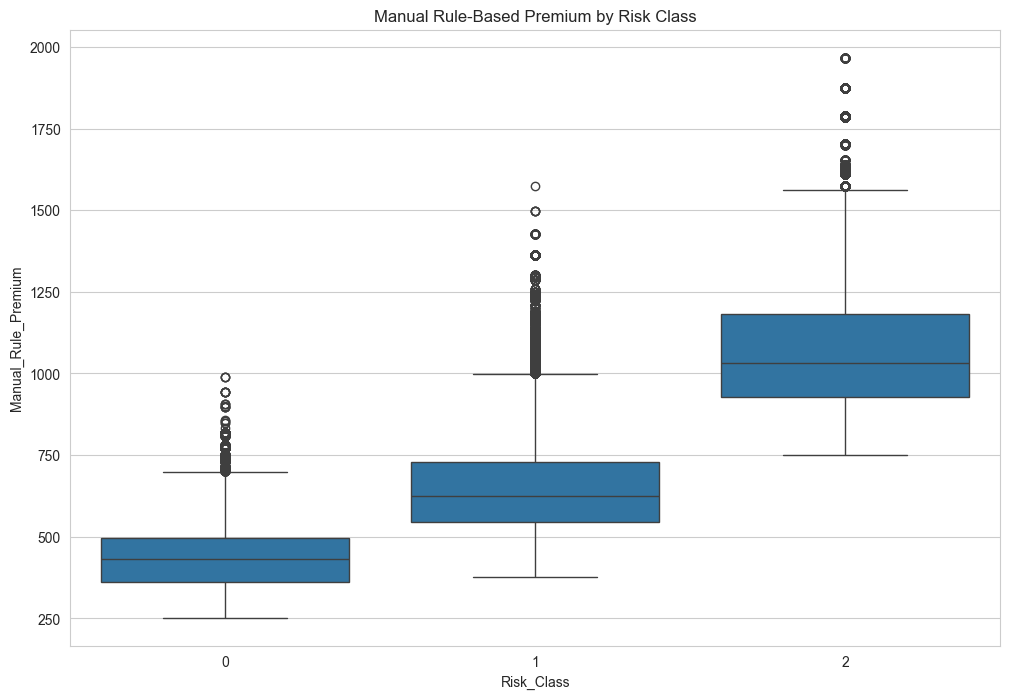

In [54]:
sns.boxplot(
    data=df,
    x=RISK_CLASS_COL,
    y="Manual_Rule_Premium"
)
plt.title("Manual Rule-Based Premium by Risk Class")
plt.show()

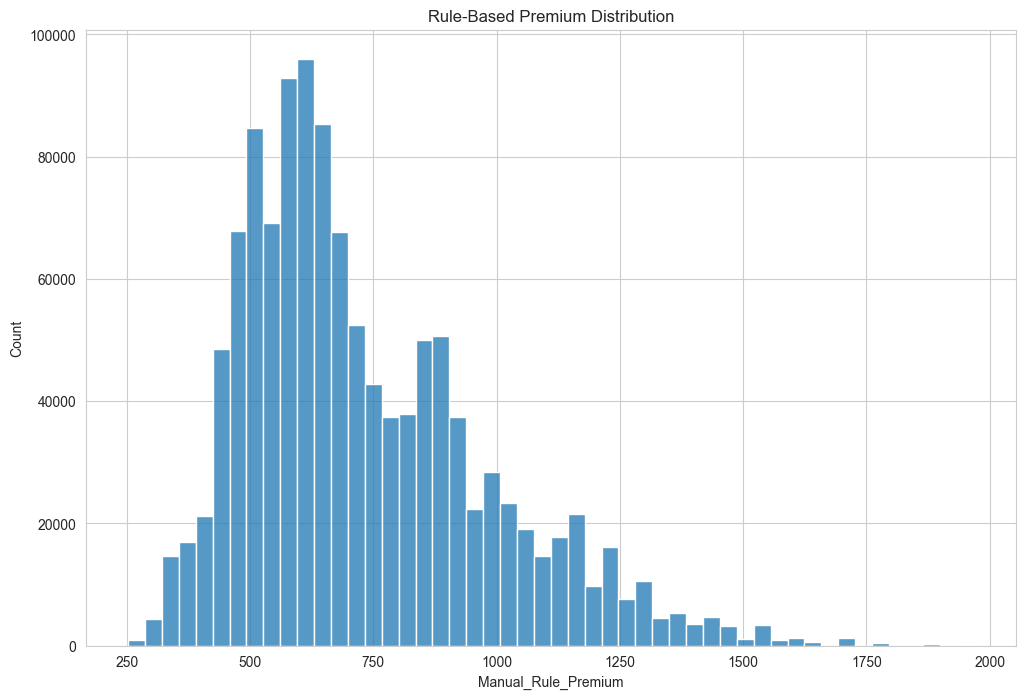

In [55]:
sns.histplot(x=df["Manual_Rule_Premium"], bins=50)
plt.title("Rule-Based Premium Distribution")
plt.show()

In [56]:
def simulate_ideal_premium(risk_class):
    if risk_class == 0:
        return np.random.uniform(400, 800)
    elif risk_class == 1:
        return np.random.uniform(800, 1200)
    else:
        return np.random.uniform(1200, 2000)

np.random.seed(42)
df["Manual_Ideal_Premium"] = df[RISK_CLASS_COL].apply(simulate_ideal_premium)
df[["Manual_Ideal_Premium"]].describe()

,Manual_Ideal_Premium
count,1.200000e+06
mean,1.108567e+03
std,3.267215e+02
min,4.000009e+02
25%,9.001597e+02
50%,1.044849e+03
75%,1.189596e+03
max,1.999998e+03


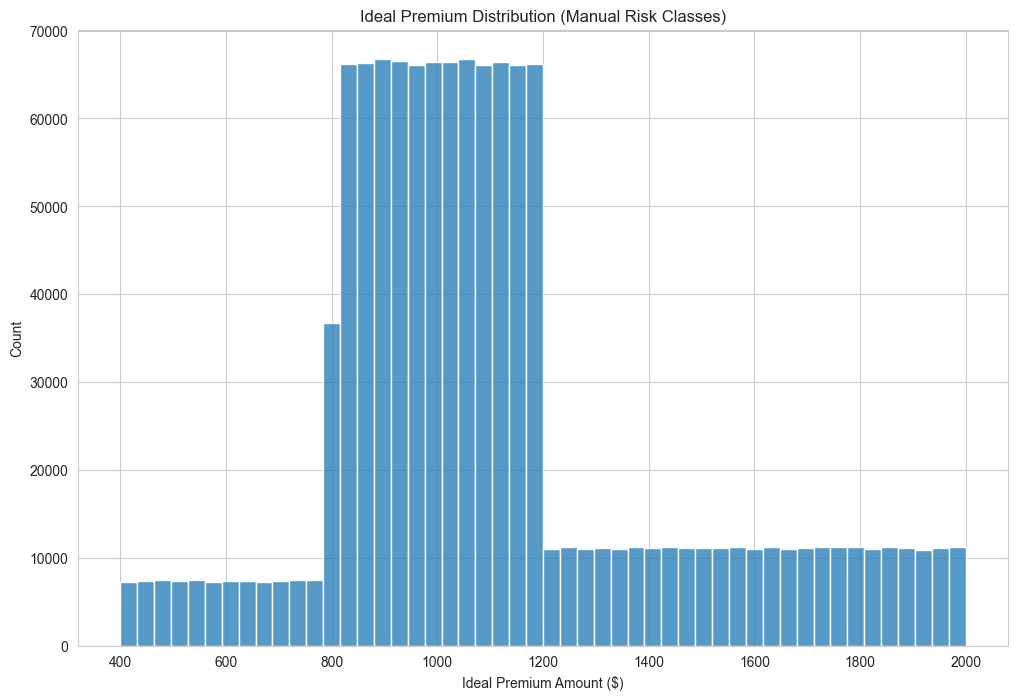

In [57]:
sns.histplot(data=df, x="Manual_Ideal_Premium", bins=50)
plt.title("Ideal Premium Distribution (Manual Risk Classes)")
plt.xlabel("Ideal Premium Amount ($)")
plt.ylabel("Count")
plt.show()

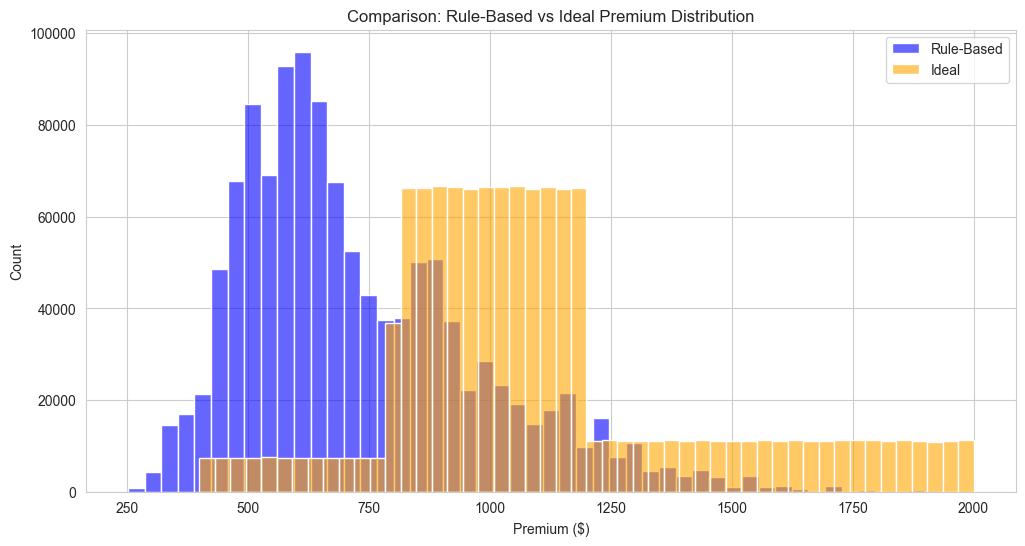

In [58]:
plt.figure(figsize=(12,6))

sns.histplot(data=df, x="Manual_Rule_Premium", bins=50, color="blue", label="Rule-Based", alpha=0.6)
sns.histplot(data=df, x="Manual_Ideal_Premium", bins=50, color="orange", label="Ideal", alpha=0.6)

plt.title("Comparison: Rule-Based vs Ideal Premium Distribution")
plt.xlabel("Premium ($)")
plt.ylabel("Count")
plt.legend()
plt.show()

In [59]:
feature_cols = [
    #RISK_SCORE_COL,
    RISK_CLASS_COL,
    "Age",
    "Annual Income",
    "Health Score",
    "Credit Score",
    "Previous Claims",
    "Vehicle Age"
]

X = df[feature_cols]
y = df["Manual_Ideal_Premium"]

rf_manual = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf_manual.fit(X, y)
df["Manual_RF_Premium"] = rf_manual.predict(X)

mae = mean_absolute_error(y, df["Manual_RF_Premium"])
mse = mean_squared_error(y, df["Manual_RF_Premium"])
rmse = np.sqrt(mse)
r2 = r2_score(y, df["Manual_RF_Premium"])

mae, rmse, r2

(122.47630133023516, np.float64(149.38016942948136), 0.7909592912038939)

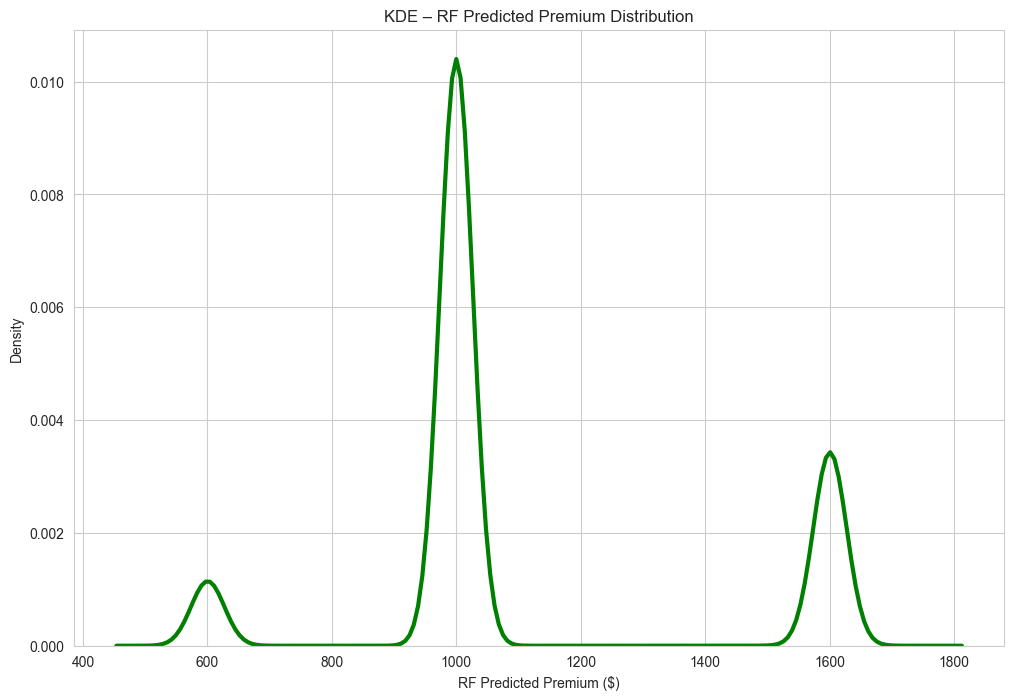

In [60]:
sns.kdeplot(
    df["Manual_RF_Premium"],
    bw_adjust=1.5,
    color="green",
    linewidth=3
)
plt.title("KDE – RF Predicted Premium Distribution")
plt.xlabel("RF Predicted Premium ($)")
plt.ylabel("Density")
plt.show()

In [61]:
importances = pd.Series(rf_manual.feature_importances_, index=feature_cols)
importances.sort_values(ascending=False)

Risk_Class         0.996837
Health Score       0.000828
Annual Income      0.000787
Credit Score       0.000631
Age                0.000416
Vehicle Age        0.000301
Previous Claims    0.000199
dtype: float64

In [62]:
def summarize_by_class(premium_col):
    return df.groupby(RISK_CLASS_COL)[premium_col].agg(["mean", "median", "min", "max", "std"])

summarize_by_class("Manual_Rule_Premium")
summarize_by_class("Manual_RF_Premium")
summarize_by_class("Manual_Ideal_Premium")

,mean,median,min,max,std
Risk_Class,,,,,
0,600.341990,600.240091,400.000891,799.994769,115.564006
1,999.976510,999.982214,800.000202,1199.999326,115.414300
2,1600.425569,1600.524098,1200.005258,1999.998225,230.794947


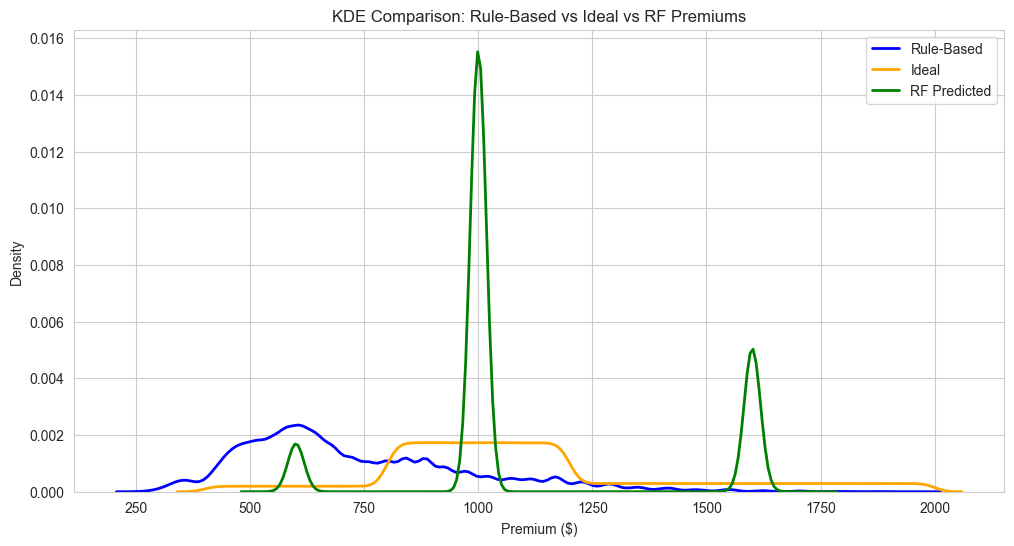

In [63]:
plt.figure(figsize=(12,6))

sns.kdeplot(df["Manual_Rule_Premium"], color="blue", linewidth=2, label="Rule-Based")
sns.kdeplot(df["Manual_Ideal_Premium"], color="orange", linewidth=2, label="Ideal")
sns.kdeplot(df["Manual_RF_Premium"], color="green", linewidth=2, label="RF Predicted")

plt.title("KDE Comparison: Rule-Based vs Ideal vs RF Premiums")
plt.xlabel("Premium ($)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [64]:
output_file = "../data/data_with_manual_premiums.csv"

df.to_csv(output_file, index=False)

print("Saved updated manual premium dataset to:", output_file)

Saved updated manual premium dataset to: ../data/data_with_manual_premiums.csv
